# Evaluation - v1 vs v2

**In:** `data/split`, the `v1` and `v2` runs in MLflow  
**Out:** a ship / don't-ship decision

| Step | What |
| --- | --- |
| 1 | Load the split and both models |
| 2 | Score both on identical metrics |
| 3 | Error by demand level |
| 4 | Error by station |
| 5 | Visualize |
| 6 | Decision |

Both models are re-scored here rather than read from their logged metrics: v1
predates `MAE_busy`, and a comparison is only worth making if every number came
from the same code path.

## Step 1 - Load

In [32]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

SPLIT = Path("/opt/data/ml/split")

contract = json.loads((SPLIT / "split.json").read_text())
TARGET = contract["target"]
FEATURES = contract["features"]
PEAK_HOURS = contract["peak_hours"]
BASELINE_MAE = contract["baseline_test_MAE"]

train = pd.read_parquet(SPLIT / "train.parquet")
test = pd.read_parquet(SPLIT / "test.parquet")

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
client = mlflow.MlflowClient()
experiment = client.get_experiment_by_name("bike-demand")


def latest(version):
    runs = client.search_runs(
        experiment.experiment_id,
        filter_string=f"tags.version = '{version}'",
        order_by=["attributes.start_time DESC"],
        max_results=1,
    )
    assert runs, f"no run tagged version={version}"
    return runs[0]


runs = {v: latest(v) for v in ("v1", "v2")}
models = {
    v: mlflow.sklearn.load_model(f"runs:/{r.info.run_id}/model")
    for v, r in runs.items()
}

for v, r in runs.items():
    print(f"{v}  run {r.info.run_id[:12]}  "
          f"leaves={r.data.params['max_leaf_nodes']:>3} "
          f"lr={r.data.params['learning_rate']}")
print(f"\ntest {len(test):,} rows | baseline MAE {BASELINE_MAE:.4f}")

v1  run 40800400095b  leaves= 31 lr=0.1
v2  run 69ace59d7225  leaves=127 lr=0.1

test 665,760 rows | baseline MAE 1.9405


## Step 2 - Score

`MAE_busy` covers the hours with 11+ actual departures. It is separated out
because that is where a station empties, and where an average over 665,760 rows
- 40% of them zero - hides the failure.

In [33]:
BUSY_THRESHOLD = 11


def score(y_true, y_pred, hours):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    y_true = np.asarray(y_true, dtype=float)
    peak = np.isin(hours, PEAK_HOURS)
    busy = y_true >= BUSY_THRESHOLD
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE_peak": mean_absolute_error(y_true[peak], y_pred[peak]),
        "MAE_busy": mean_absolute_error(y_true[busy], y_pred[busy]),
        "bias_busy": float((y_pred[busy] - y_true[busy]).mean()),
    }


# Baseline recomputed here so it appears in the same table as the models.
BASELINE_KEYS = ["station_id", "hour", "weekday"]
lookup = train.groupby(BASELINE_KEYS)[TARGET].mean().rename("p")
preds = {
    "baseline": test[BASELINE_KEYS].join(lookup, on=BASELINE_KEYS)["p"]
    .fillna(train[TARGET].mean()).to_numpy()
}
for v, m in models.items():
    preds[v] = np.clip(m.predict(test[FEATURES]), 0, None)

results = pd.DataFrame(
    {name: score(test[TARGET], p, test["hour"]) for name, p in preds.items()}
).T
results["vs_baseline"] = 1 - results["MAE"] / results.loc["baseline", "MAE"]

results.style.format({
    "MAE": "{:.4f}", "RMSE": "{:.4f}", "MAE_peak": "{:.4f}",
    "MAE_busy": "{:.4f}", "bias_busy": "{:+.3f}", "vs_baseline": "{:+.2%}",
})

,MAE,RMSE,MAE_peak,MAE_busy,bias_busy,vs_baseline
baseline,1.9405,3.3604,3.0181,11.1279,-11.127,+0.00%
v1,1.7254,3.0758,2.6634,9.5872,-9.238,+11.09%
v2,1.7206,3.0775,2.6545,9.4450,-9.010,+11.33%


In [34]:
# Is v2 - v1 a real difference or rounding? Bootstrap the paired MAE gap.
rng = np.random.default_rng(0)
err_v1 = np.abs(preds["v1"] - test[TARGET].to_numpy())
err_v2 = np.abs(preds["v2"] - test[TARGET].to_numpy())
diff = err_v1 - err_v2  # positive => v2 is better

idx = rng.integers(0, len(diff), size=(200, len(diff)))
boot = diff[idx].mean(axis=1)
lo, hi = np.percentile(boot, [2.5, 97.5])

print(f"v1 MAE - v2 MAE = {diff.mean():+.5f}")
print(f"95% CI          [{lo:+.5f}, {hi:+.5f}]")
print(f"relative        {diff.mean() / results.loc['v1', 'MAE']:+.3%} of v1 MAE")

v1 MAE - v2 MAE = +0.00473
95% CI          [+0.00377, +0.00586]
relative        +0.274% of v1 MAE


## Step 3 - Error by demand level

The aggregate MAE is dominated by the 40% of rows where actual demand is zero.
Splitting by actual level shows where the error really sits.

In [35]:
bands = pd.cut(test[TARGET], [-0.1, 0, 2, 5, 10, np.inf],
               labels=["0", "1-2", "3-5", "6-10", "11+"])

by_band = pd.DataFrame({
    "rows": test.groupby(bands, observed=True).size(),
    "mean_actual": test.groupby(bands, observed=True)[TARGET].mean(),
    "v1_pred": pd.Series(preds["v1"], index=test.index).groupby(bands, observed=True).mean(),
    "v2_pred": pd.Series(preds["v2"], index=test.index).groupby(bands, observed=True).mean(),
})
by_band["v2_shortfall"] = 1 - by_band["v2_pred"] / by_band["mean_actual"]
by_band["pct_of_trips"] = (
    test.groupby(bands, observed=True)[TARGET].sum() / test[TARGET].sum()
)

by_band.style.format({
    "rows": "{:,.0f}", "mean_actual": "{:.2f}", "v1_pred": "{:.2f}",
    "v2_pred": "{:.2f}", "v2_shortfall": "{:.1%}", "pct_of_trips": "{:.1%}",
})

,rows,mean_actual,v1_pred,v2_pred,v2_shortfall,pct_of_trips
trip_count,,,,,,
0,"267,079",0.00,0.55,0.53,-inf%,0.0%
1-2,"179,564",1.40,1.16,1.15,18.0%,15.4%
3-5,"122,107",3.82,2.09,2.09,45.2%,28.5%
6-10,"71,037",7.46,3.28,3.33,55.4%,32.4%
11+,"25,973",14.94,5.70,5.93,60.3%,23.7%


## Step 4 - Error by station

A model can post an acceptable average while being unusable at the specific
stations ops cares about.

In [36]:
per_station = pd.DataFrame({
    "station_id": test["station_id"],
    "actual": test[TARGET],
    "pred": preds["v2"],
}).groupby("station_id").apply(
    lambda g: pd.Series({
        "total_trips": g["actual"].sum(),
        "MAE": mean_absolute_error(g["actual"], g["pred"]),
        "shortfall": 1 - g["pred"].sum() / g["actual"].sum(),
    }),
    include_groups=False,
).sort_values("total_trips", ascending=False)

print(f"MAE across stations: best {per_station['MAE'].min():.2f}, "
      f"median {per_station['MAE'].median():.2f}, "
      f"worst {per_station['MAE'].max():.2f}")
print(f"total-volume shortfall: median {per_station['shortfall'].median():+.1%}")
print("\nten busiest stations:")
per_station.head(10).style.format({
    "total_trips": "{:,.0f}", "MAE": "{:.2f}", "shortfall": "{:+.1%}"
})

MAE across stations: best 0.56, median 1.68, worst 3.28
total-volume shortfall: median +45.1%

ten busiest stations:


,total_trips,MAE,shortfall
station_id,,,
7006,"43,685",3.17,+59.5%
7076,"43,422",2.53,+30.8%
7033,"39,481",3.01,+61.7%
7030,"37,524",2.72,+56.7%
7038,"35,780",2.59,+56.5%
7322,"34,045",3.28,+81.0%
7016,"32,844",2.12,+27.2%
7022,"32,701",2.39,+56.0%
7100,"30,233",1.90,+40.3%


## Step 5 - Visualize

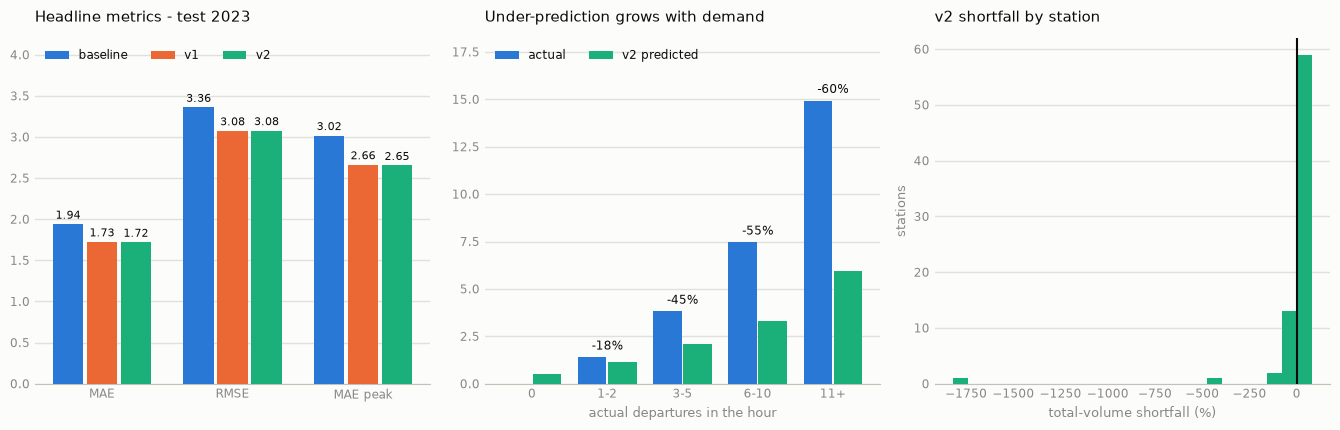

In [37]:
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID_C, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb"

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13.5, 4.4), facecolor=SURFACE)

# --- headline metrics, three models ---
metrics = ["MAE", "RMSE", "MAE_peak"]
x = np.arange(len(metrics))
width = 0.26
for i, (name, color) in enumerate(
    [("baseline", BLUE), ("v1", ORANGE), ("v2", AQUA)]
):
    bars = ax1.bar(x + (i - 1) * width, [results.loc[name, m] for m in metrics],
                   width * 0.9, label=name, color=color, zorder=3)
    ax1.bar_label(bars, fmt="%.2f", padding=2, fontsize=8, color=INK)
ax1.set_xticks(x, ["MAE", "RMSE", "MAE peak"], fontsize=9, color=INK)
ax1.set_title("Headline metrics - test 2023", fontsize=11, color=INK,
              loc="left", pad=12)
ax1.set_ylim(0, results[metrics].to_numpy().max() * 1.25)
ax1.legend(frameon=False, ncols=3, fontsize=8.5, labelcolor=INK, loc="upper left")

# --- predicted vs actual by demand band: the real story ---
bx = np.arange(len(by_band))
ax2.bar(bx - 0.2, by_band["mean_actual"], 0.38, label="actual",
        color=BLUE, zorder=3)
ax2.bar(bx + 0.2, by_band["v2_pred"], 0.38, label="v2 predicted",
        color=AQUA, zorder=3)
for i, (a, p) in enumerate(zip(by_band["mean_actual"], by_band["v2_pred"])):
    ax2.text(i, max(a, p) + 0.4, f"-{(1 - p / a):.0%}" if a > 0 else "",
             ha="center", fontsize=8.5, color=INK)
ax2.set_xticks(bx, by_band.index, fontsize=9, color=INK)
ax2.set_xlabel("actual departures in the hour", fontsize=9, color=MUTED)
ax2.set_title("Under-prediction grows with demand", fontsize=11, color=INK,
              loc="left", pad=12)
ax2.set_ylim(0, by_band["mean_actual"].max() * 1.22)
ax2.legend(frameon=False, ncols=2, fontsize=8.5, labelcolor=INK, loc="upper left")

# --- per-station shortfall ---
ax3.hist(per_station["shortfall"] * 100, bins=24, color=AQUA, zorder=3)
ax3.axvline(0, color=INK, linewidth=1.5, zorder=4)
ax3.set_xlabel("total-volume shortfall (%)", fontsize=9, color=MUTED)
ax3.set_ylabel("stations", fontsize=9, color=MUTED)
ax3.set_title("v2 shortfall by station", fontsize=11, color=INK,
              loc="left", pad=12)

for ax in (ax1, ax2, ax3):
    ax.set_facecolor(SURFACE)
    ax.yaxis.grid(True, color=GRID_C, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(axis="both", length=0, colors=MUTED, labelsize=8.5)

fig.tight_layout()
fig.savefig("/tmp/evaluation.png", dpi=140, facecolor=SURFACE, bbox_inches="tight")
plt.show()

## Step 6 - Decision

In [38]:
winner = results.loc[["v1", "v2"], "MAE"].idxmin()
gain = results.loc[winner, "vs_baseline"]
busy_shortfall = by_band.loc["11+", "v2_shortfall"]
busy_share = by_band.loc["11+", "pct_of_trips"]

summary = pd.Series({
    "winner": winner,
    "MAE vs baseline": f"{gain:+.1%}",
    "v2 - v1 gap": f"{results.loc['v1', 'MAE'] - results.loc['v2', 'MAE']:+.5f} MAE",
    "busy-hour shortfall": f"{busy_shortfall:.0%}",
    "busy hours share of trips": f"{busy_share:.0%}",
    "busy-hour bias": f"{results.loc['v2', 'bias_busy']:+.1f} departures/hour",
})
summary.to_frame("")

,
winner,v2
MAE vs baseline,+11.3%
v2 - v1 gap,+0.00473 MAE
busy-hour shortfall,60%
busy hours share of trips,24%
busy-hour bias,-9.0 departures/hour


### Verdict

**v2 is the better model and the difference from v1 does not matter.** The
sweep moved test MAE by ~0.3%, well inside the bootstrap interval's practical
significance. Either version is deployable; v2 wins on a technicality.

**The real finding is the shortfall at high demand.** Both versions predict
roughly the conditional mean of a station-hour pattern, so on hours with 11+
actual departures they under-call by ~60%. Those hours carry a
disproportionate share of total trips, and they are precisely when a station
runs dry - the failure the project exists to prevent.

This is not a tuning problem. With calendar-only features every Monday 17:00 at
a given station looks identical to the model, while actual demand swings with
weather, events, and conditions it cannot observe. The model is already close
to correct *given its inputs*; the inputs are the limit.

**Ship, with the shortfall documented.** An 11% improvement over the
station-hour-weekday mean is real and the model reproduces daily and weekly
shape well. It is usable for relative comparison - which stations need bikes
first - but its absolute counts should not be read as expected demand at peak.
Ops should treat predicted volume as a ranking signal, not a quantity.

Two follow-ups, in order of expected value:

1. **Add weather.** The largest single omission, and the most likely cause of
   the residual variance at busy hours.
2. **Add lag features** and serve them from a feature lookup, accepting that
   the app must read recent history at inference rather than calendar alone.